## Exploratory Data Analysis of UPI Transactions in India
### Objective

***The objective of this project is to analyse India's Unified Payments Interface (UPI) transaction data to understand its growth, transaction volume, participating banks, and transaction values over time. The analysis uses Python, Pandas, NumPy, Matplotlib, and Seaborn to clean, explore, visualise, and answer business questions from the dataset.***

In [1]:
# Importing Python libraries used in the project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




In [5]:
# Reading the csv file using the read_csv method of Pandas library

df=pd.read_csv('/kaggle/input/datasets/ramjasmaurya/upi-apps-transactions-in-2021/UPI apps transaction data in 2021.csv')


In [ ]:
# Displays top 5 records
df.head()

In [ ]:
# Displays Bottom 5 records
df.tail()

### Data Dictionary:

* UPI Banks
* Volume (Mn) By Costumers
* Value (Cr) by Costumers
* Volume (Mn)
* Value (Cr)
* Month
* Year

### Understanding the Dataset

In [46]:
# Data type of the Dataset
type(df)

pandas.core.frame.DataFrame

In [47]:
# Displays rows and columns
df.shape

(654, 7)

In [6]:
# Displays the columns

df.columns.tolist()

['UPI Banks',
 'Volume (Mn) By Costumers',
 'Value (Cr) by Costumers',
 'Volume (Mn)',
 'Value (Cr)',
 'Month',
 'Year']

In [49]:
# Dataset info like total rows & columns, datatypes, memory usage, non-null values, etc

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 654 entries, 0 to 653
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   UPI Banks                 654 non-null    object 
 1   Volume (Mn) By Costumers  654 non-null    float64
 2   Value (Cr) by Costumers   654 non-null    float64
 3   Volume (Mn)               654 non-null    float64
 4   Value (Cr)                654 non-null    float64
 5   Month                     654 non-null    int64  
 6   Year                      654 non-null    int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 35.9+ KB


### Data Cleaning and Preprocesing

In [52]:
# check for missing values in each column

df.isnull().sum()     # no null values found

UPI Banks                   0
Volume (Mn) By Costumers    0
Value (Cr) by Costumers     0
Volume (Mn)                 0
Value (Cr)                  0
Month                       0
Year                        0
dtype: int64

In [7]:
# Calculate missing value percentage

miss_val= (df.isna().sum()/len(df))*100
round(miss_val,2)

UPI Banks                   0.0
Volume (Mn) By Costumers    0.0
Value (Cr) by Costumers     0.0
Volume (Mn)                 0.0
Value (Cr)                  0.0
Month                       0.0
Year                        0.0
dtype: float64

In [8]:
# If null values exists

df.fillna(0, inplace=True)

In [53]:
# Check for duplicate records
df.duplicated().sum()        # No duplicates found 

np.int64(0)

In [54]:
# If duplicates exists

df.drop_duplicates(inplace=True)

In [55]:
# Displays datatype of each column
df.dtypes

UPI Banks                    object
Volume (Mn) By Costumers    float64
Value (Cr) by Costumers     float64
Volume (Mn)                 float64
Value (Cr)                  float64
Month                         int64
Year                          int64
dtype: object

In [23]:
# Count of Unique UPI Apps
df["UPI Banks"].nunique()

69

In [24]:
# Displays all the unique UPI Apps
df["UPI Banks"].unique()

array(['Airtel Payments Bank Apps', 'Allahabad Bank App', 'Amazon Pay',
       'Andhra Bank App', 'AU Small Finance Bank App', 'Axis Bank Apps',
       'Bajaj Finserv', 'Bank of Baroda Apps', 'Bank of India App',
       'Bank of Maharashtra App', 'BHIM', 'Canara Bank App',
       'Central Bank of India App', 'Citi Bank App',
       'City Union Bank App', 'Cointab', 'Cred', 'DBS Digibank App',
       'Dena Bank App', 'Deutsche Bank App', 'Dhanlaxmi Bank App',
       'Federal Bank App', 'Fino Payments bank App', 'Finshell Pay',
       'Freecharge', 'Goibibo', 'Google Pay', 'HDFC Bank Apps',
       'HSBC Bank App', 'ICICI Bank Apps', 'IDBI Bank App',
       'IDFC Bank App', 'India Post Payments Bank App', 'Indian Bank App',
       'IndusInd Bank App', 'Jammu and Kashmir Bank App',
       'Janta Sahakari Bank App', 'Jio Payments Bank App',
       'Jupiter Money', 'Karnataka Bank App', 'Karur Vysya Bank App',
       'Khalijeb', 'Kotak Mahindra Bank Apps', 'MakeMy Trip', 'MI Pay',
       'Mo

In [9]:
# Create a new column called MonthName

df["MonthName"] = pd.to_datetime(
    df["Month"],
    format="%m"
).dt.month_name()

In [10]:
df['MonthName']

0       December
1       November
2        October
3      September
4         August
         ...    
649         June
650          May
651        April
652        March
653     February
Name: MonthName, Length: 654, dtype: object

In [35]:
# Displaying the unique values in the month-year columns 

df["MonthName"].unique()

array(['December', 'November', 'October', 'September', 'August', 'July',
       'June', 'May', 'April', 'March', 'February', 'January'],
      dtype=object)

In [12]:
# Create a Date column
df["Date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" + df["Month"].astype(str) + "-01"
)

In [13]:
df['Date']

0     2021-12-01
1     2021-11-01
2     2021-10-01
3     2021-09-01
4     2021-08-01
         ...    
649   2021-06-01
650   2021-05-01
651   2021-04-01
652   2021-03-01
653   2021-02-01
Name: Date, Length: 654, dtype: datetime64[ns]

### Exploratory Data Analysis (EDA) and Visualization

In [28]:
# Only for numerical data
df.describe()

,Volume (Mn) By Costumers,Value (Cr) by Costumers,Volume (Mn),Value (Cr),Month,Year,Month_Name,Date
count,654.000000,654.000000,654.000000,654.000000,654.000000,654.0,654,654
mean,57.960948,10943.292813,60.460321,11134.196682,6.571865,2021.0,1900-06-18 16:48:26.422018304,2021-06-18 16:48:26.422018304
min,0.010000,0.410000,0.010000,0.410000,1.000000,2021.0,1900-01-01 00:00:00,2021-01-01 00:00:00
25%,0.050000,21.132500,0.050000,21.132500,3.250000,2021.0,1900-03-08 18:00:00,2021-03-08 18:00:00
50%,0.250000,60.640000,0.250000,60.745000,7.000000,2021.0,1900-07-01 00:00:00,2021-07-01 00:00:00
75%,2.357500,401.312500,2.357500,407.062500,10.000000,2021.0,1900-10-01 00:00:00,2021-10-01 00:00:00
max,2077.600000,394565.580000,2077.600000,394565.580000,12.000000,2021.0,1900-12-01 00:00:00,2021-12-01 00:00:00
std,256.842682,49450.615924,258.686922,49588.538504,3.488797,0.0,NaN,NaN


In [29]:
# For non-numerical data

df.describe(include='object')

,UPI Banks,MonthName
count,654,654
unique,69,12
top,Airtel Payments Bank Apps,December
freq,12,58


In [30]:
# Statistical analysis for all data
df.describe(include='all')

,UPI Banks,Volume (Mn) By Costumers,Value (Cr) by Costumers,Volume (Mn),Value (Cr),Month,Year,Month_Name,MonthName,Date
count,654,654.000000,654.000000,654.000000,654.000000,654.000000,654.0,654,654,654
unique,69,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12,NaN
top,Airtel Payments Bank Apps,NaN,NaN,NaN,NaN,NaN,NaN,NaN,December,NaN
freq,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58,NaN
mean,NaN,57.960948,10943.292813,60.460321,11134.196682,6.571865,2021.0,1900-06-18 16:48:26.422018304,NaN,2021-06-18 16:48:26.422018304
min,NaN,0.010000,0.410000,0.010000,0.410000,1.000000,2021.0,1900-01-01 00:00:00,NaN,2021-01-01 00:00:00
25%,NaN,0.050000,21.132500,0.050000,21.132500,3.250000,2021.0,1900-03-08 18:00:00,NaN,2021-03-08 18:00:00
50%,NaN,0.250000,60.640000,0.250000,60.745000,7.000000,2021.0,1900-07-01 00:00:00,NaN,2021-07-01 00:00:00
75%,NaN,2.357500,401.312500,2.357500,407.062500,10.000000,2021.0,1900-10-01 00:00:00,NaN,2021-10-01 00:00:00
max,NaN,2077.600000,394565.580000,2077.600000,394565.580000,12.000000,2021.0,1900-12-01 00:00:00,NaN,2021-12-01 00:00:00


In [14]:
# Verifying the values 
df.mean(numeric_only=True)
df.median(numeric_only=True)
df.mode(numeric_only=True)
df.max(numeric_only=True)
df.min(numeric_only=True)
df.std(numeric_only=True)

Volume (Mn) By Costumers      256.842682
Value (Cr) by Costumers     49450.615924
Volume (Mn)                   258.686922
Value (Cr)                  49588.538504
Month                           3.488797
Year                            0.000000
dtype: float64

### Business Questions and Visualization

1. Correlation Analysis among the dataset


In [40]:
correlation = df.corr(numeric_only=True)
correlation

,Year,No.Of.Banks.Using.Upi,Volume.Of.Transaction.in.Mn,Amount.Of.Transaction,Amount.Of.Transaction.In.Bn
Year,1.000000,0.945227,0.895461,0.899989,0.899989
No.Of.Banks.Using.Upi,0.945227,1.000000,0.881116,0.886029,0.886029
Volume.Of.Transaction.in.Mn,0.895461,0.881116,1.000000,0.994077,0.994077
Amount.Of.Transaction,0.899989,0.886029,0.994077,1.000000,1.000000
Amount.Of.Transaction.In.Bn,0.899989,0.886029,0.994077,1.000000,1.000000


***Correlation values range from -1 to +1.***

* +1 → Perfect positive relationship
* 0 → No relationship
* -1 → Perfect negative relationship

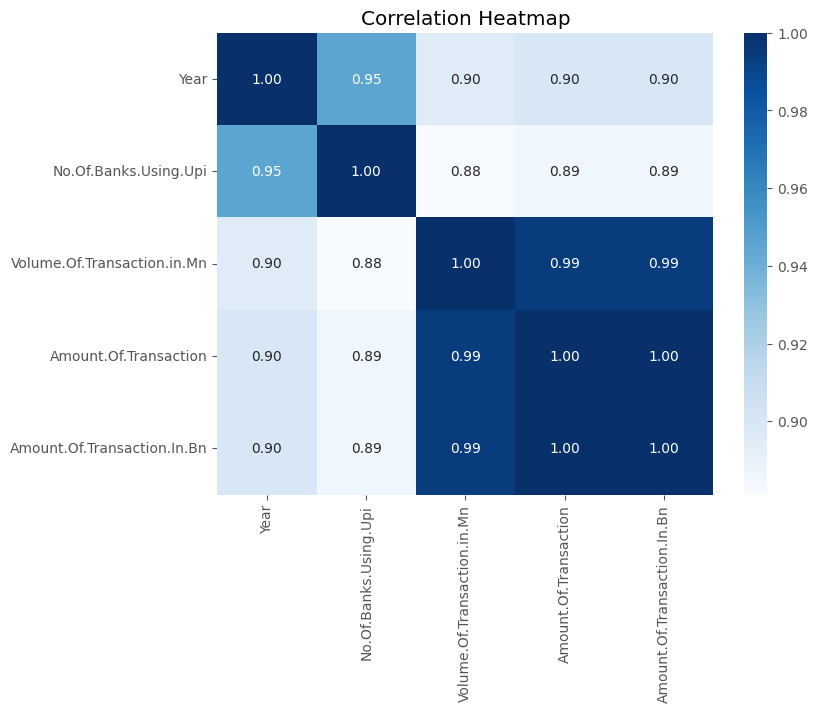

In [41]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

2. Distribution of Customer Transaction Volume

In [12]:
df['Volume (Mn) By Costumers'].value_counts()

Volume (Mn) By Costumers
0.01    54
0.02    48
0.03    30
0.08    25
0.09    20
        ..
1.15     1
1.49     1
0.89     1
0.24     1
6.14     1
Name: count, Length: 279, dtype: int64

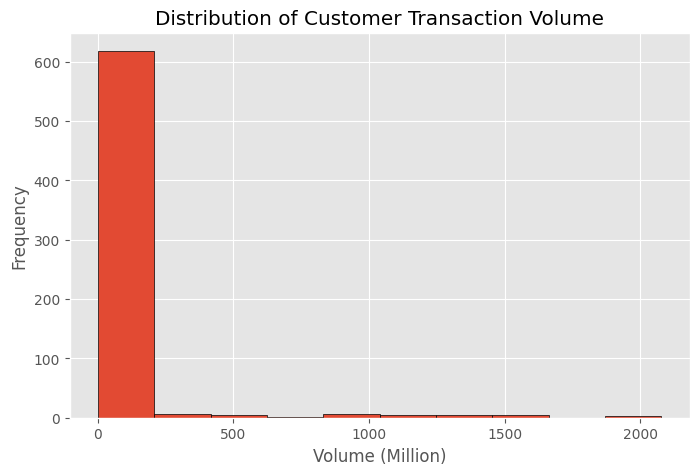

In [15]:
plt.figure(figsize=(8,5))

plt.hist(
    df["Volume (Mn) By Costumers"],
    bins=10,
    edgecolor="Black"
)

plt.title("Distribution of Customer Transaction Volume")

plt.xlabel("Volume (Million)")

plt.ylabel("Frequency")

plt.show()


3. What is the monthly transaction trend, and which month has the highest volume (Mn)? 

In [16]:
vol=df.groupby('MonthName')["Volume (Mn)"].sum().sort_values(ascending=False)
vol

MonthName
December     4658.05
October      4306.89
November     4273.67
September    3732.73
August       3627.60
July         3311.52
June         2861.04
March        2785.05
April        2702.49
May          2591.12
January      2350.74
February     2340.15
Name: Volume (Mn), dtype: float64

In [50]:
vol.idxmax()

'December'

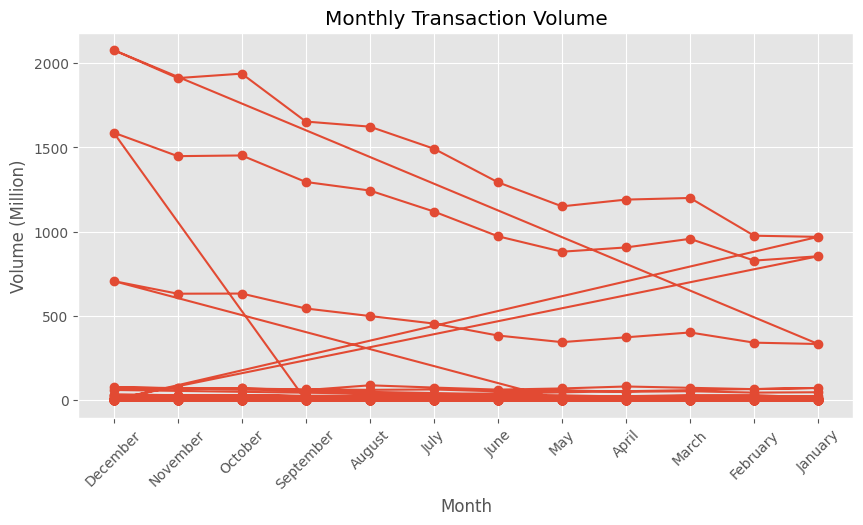

In [17]:
plt.figure(figsize=(10,5))

plt.plot(
    df["MonthName"],
    df["Volume (Mn)"],
    marker="o"
)

plt.title("Monthly Transaction Volume")

plt.xlabel("Month")

plt.ylabel("Volume (Million)")

plt.xticks(rotation=45)

plt.show()

***December has the highest volume (Mn)***

4. Top 10 UPI Apps by Transaction Volume

In [18]:
vol=df.groupby('UPI Banks')['Volume (Mn)'].sum().sort_values(ascending=False).head(10)
vol

UPI Banks
PhonePe                      17470.81
Google Pay                   13541.88
Paytm Payments Bank App       5640.23
Axis Bank Apps                 841.62
Amazon Pay                     704.15
Yes Bank Apps                  293.08
BHIM                           289.43
ICICI Bank Apps                227.74
Airtel Payments Bank Apps      109.80
Cred                            80.96
Name: Volume (Mn), dtype: float64

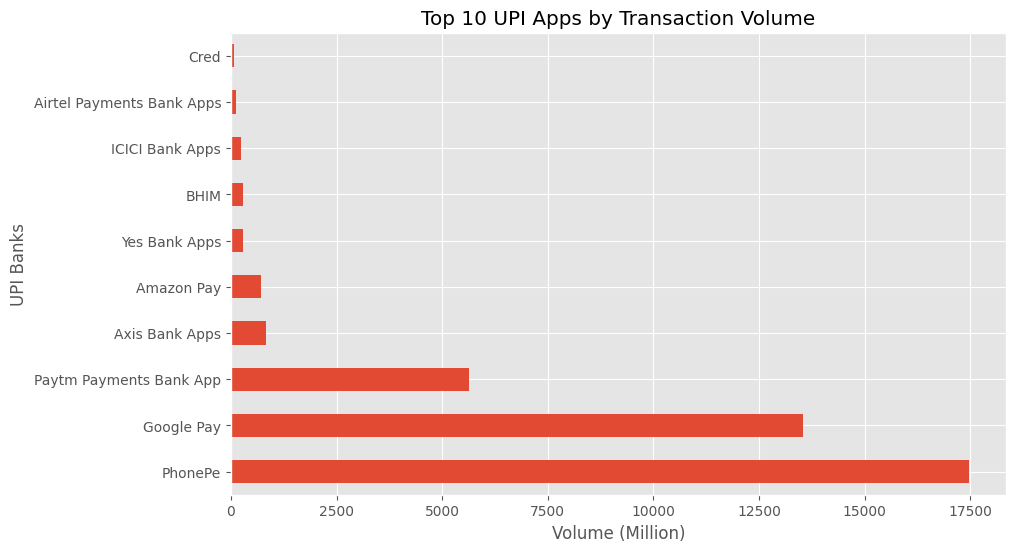

In [19]:
plt.figure(figsize=(10,6))

vol.plot(
    kind="barh"
)

plt.title("Top 10 UPI Apps by Transaction Volume")

plt.xlabel("Volume (Million)")

plt.ylabel("UPI Banks")

plt.show()

***PhonePe has highest transaction volumn***

5. Is there a relationship between transaction volume and transaction value?

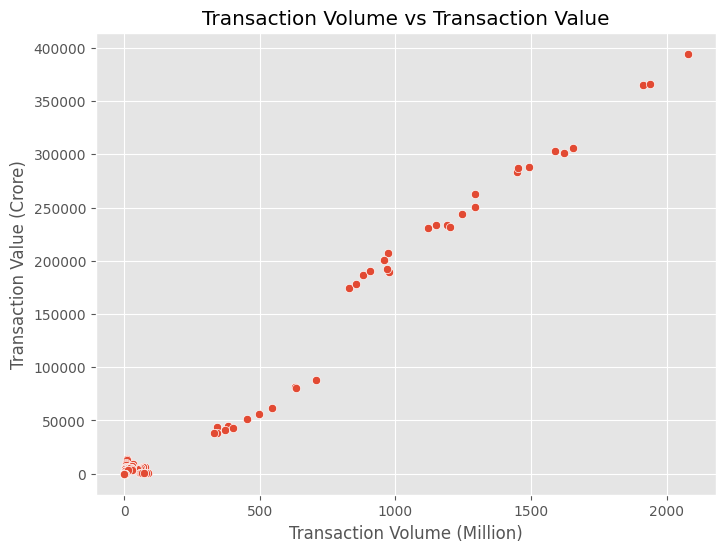

In [66]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Volume (Mn)",
    y="Value (Cr)"
)

plt.title("Transaction Volume vs Transaction Value")
plt.xlabel("Transaction Volume (Million)")
plt.ylabel("Transaction Value (Crore)")

plt.show()

***This means apps processing more transactions also process larger monetary values.***

6. Which UPI apps have the highest average transaction value per month?

In [20]:
average_value = (
    df.groupby(["UPI Banks","MonthName"])["Value (Cr)"]
      .mean()
      .sort_values(ascending=False)
)

round(average_value,2)

UPI Banks               MonthName
PhonePe                 December     394565.58
                        October      365845.39
                        November     365044.32
                        September    306437.37
Google Pay              December     302989.79
                                       ...    
Bajaj Finserv           May               0.77
Finshell Pay            September         0.72
YuvaPay                 February          0.63
NSDL Payments Bank App  May               0.58
RealMe                  August            0.41
Name: Value (Cr), Length: 654, dtype: float64

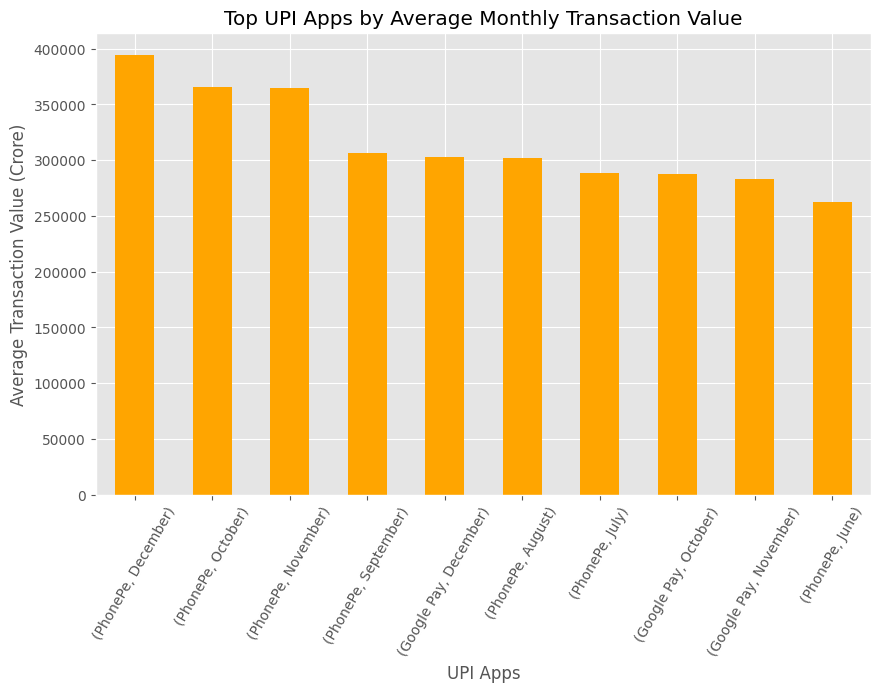

In [21]:
plt.figure(figsize=(10,6))

average_value.head(10).plot(
    kind="bar",
    color="orange"
)

plt.title("Top UPI Apps by Average Monthly Transaction Value")
plt.xlabel("UPI Apps")
plt.ylabel("Average Transaction Value (Crore)")

plt.xticks(rotation=60)

plt.show()

***Phonepe app have the highest average transaction in December Month***

### Conclusion

This Exploratory Data Analysis (EDA) project analysed UPI application transaction data for the year 2021. The dataset contained transaction volume, transaction value, customer transaction volume, customer transaction value, month, year, and UPI application details.

The data was first cleaned and preprocessed by checking for missing values, duplicate records, and verifying data types. Additional features such as MonthName and Date were created to improve time-based analysis.

Exploratory Data Analysis revealed valuable insights into the transaction behaviour of different UPI applications. Statistical summaries, correlation analysis, and various visualisations helped identify transaction trends and relationships among the variables.

Business analysis showed that some UPI applications consistently handled higher transaction volumes and transaction values than others. Monthly trend analysis highlighted fluctuations in transaction activity throughout the year. Correlation analysis also indicated the relationship between transaction volume and transaction value.

Overall, the analysis demonstrates how digital payment platforms have experienced significant transaction activity and provides meaningful insights into the performance of various UPI applications.

# Business Recommendations

1. Lower-performing UPI Banks should analyse the strategies used by leading applications to improve adoption.

2. Marketing campaigns can be planned during months with lower transaction activity to improve customer engagement.

3. Banks should continue expanding digital payment infrastructure to support increasing transaction volumes.

4. Continuous monitoring of transaction trends can help businesses prepare for seasonal increases in digital payments.
